# Main file for AQNet use

In [1]:
# import necessary libraries

# Custom library
import AQ_net_library

# General
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from mat73 import loadmat as loadmat73
from scipy.io import loadmat 

# Neural Network
import tensorflow
from tensorflow import keras
from keras import backend as K

# Metrics
from sklearn import metrics

2025-07-01 15:22:38.306877: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-01 15:22:38.314232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751376158.322599 2401853 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751376158.325061 2401853 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751376158.331804 2401853 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
#set working directory to the folder where the script is located
CurrentDirectory = os.getcwd()
os.chdir(CurrentDirectory)

## Indicate custom parameters

### The expected format of the FHR data is:
##### - A list of Matlab files (e.g., Matonia et al.)
##### - A MATLAB table (e.g., Chudackev CTU-UHB)
##### - A list of Python numpy arrays

In [13]:
# Copy the path of the folder which contains the trained models
NetPath  = os.path.join(CurrentDirectory, "TrainedModels")  #"../TrainedModels/"
FilePath = os.path.join(CurrentDirectory, "ExampleData") #"../ExampleData/"
SavePath = os.path.join(CurrentDirectory, "predictions")  #"../Results/"

# Characteristics of the input signal ----------------------------------------------

fs    = 4   #Value in Hz. set to -1 if the signal has not been resampled to unifrom sampling rate (RR series)
units = 'bpm' #'bpm', 'ms'

# Process the ouput of the network ----------------------------------------------

#if 1, the prediction for A or Q is made only with output probability of A(or Q) equals to 1 
# and the rest is indeterminate. If 0, there is no indeterminate. and everything in between
ConfidenceThreshold = 0

# Parameters for PostProcessing
MinLen      = 3     #minimum length of state in minutes (for post processing of the network output)
SmoothPredictions = False
sigma       = 1     #standard deviation of the gaussian kernel (in minutes)


### Load the model

In [4]:
#First see if there is a model with weights, otherwise load the json file with the model architecture and then the weights

with open(os.path.join(NetPath, 'R2AttU_Net_model_hyperparams.json')) as f:
    hyperparameters = keras.models.model_from_json(f.read())

# Setting the params 
batch_size   = hyperparameters["batch_size"]
depth        = hyperparameters["depth"]
n_filters    = hyperparameters["n_filters"]
block_length = hyperparameters["block_length"]
add_noise    = False

#build the model
model = AQ_net_library.nn_architectures.R2AttU_Net(block_length, depth=depth-1, n_filters=n_filters, add_noise=add_noise).model

#load the weights
model.load_weights(os.path.join(NetPath, 'R2AttU_Netmodel_finetune.weights.h5'))


I0000 00:00:1751376159.264497 2401853 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 749 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9
/home/giuli/anaconda3/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/giuli/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'attention_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/giuli/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'attention_blo

### Load the data

In [5]:
# check if in FilePath there is a list of mat, a list of numpy or a matlab table

#How many files in the folder?
files = os.listdir(FilePath)
nfiles = len(files)

#Check the first file to see if it is a mat file or a numpy file
if files[0].endswith('.mat'):
    isMat = True
elif files[0].endswith('.npy'):
    isMat = False
else:
    #I cannot recognize the data type!
    print('The data type of the input files is not recognized. Exiting...')
    exit()

if isMat and nfiles == 1:    

    # CTU-UHB dataset
    datasetName = files[0]
    dataPath = os.path.join(FilePath, "DATA",datasetName)
    data = loadmat73(dataPath)['Dati']
    
    dataset = [element[1] for element in data]
    #check this
    dataset_names = [element[0] for element in data]

elif isMat and nfiles > 1:

    # Filter the files with the ".mat" extension
    mat_files = [file for file in files if file.endswith(".mat")]

    #create dataset as list of np.arrays
    dataset = []
    dataset_names = []

    for i in range(len(mat_files)):
        mat_data = loadmat(os.path.join(FilePath, mat_files[i]))
        key_name = list(mat_data.keys())[-1]  # Get the last key which is usually the variable name
        data = mat_data[key_name]
        data = data.flatten()
        dataset.append(data)
        dataset_names.append(mat_files[i].split('.')[0])
        
elif not isMat and nfiles == 1:

    #files_ctg contains X in name
    files_ctg = [file for file in files if 'X' in file][0]
    #names contain id
    names_ctg = [file for file in files if 'id' in file][0]
    dataset = np.load(os.path.join(FilePath, files_ctg), allow_pickle=True)
    dataset_names = np.load(os.path.join(FilePath, names_ctg), allow_pickle=True)

else:
    print('Sorry, work in progress')
    exit()
        

### Load the scaling factors

In [6]:
[mean, std] = np.load(os.path.join(NetPath, 'scaling_factors.npy'))

# Proceed with the predictions

In [7]:
if ConfidenceThreshold>0:
    Transition = True
    Threshold = np.array([0.5-0.5*ConfidenceThreshold, 0.5+0.5*ConfidenceThreshold])
else:
    Transition = False
    Threshold = np.array([0.5])


In [12]:
units

'bpm,'

/home/giuli/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['Input']
Received: inputs=Tensor(shape=(1, 2400))
  warnings.warn(msg)
I0000 00:00:1751376273.855037 2401943 service.cc:152] XLA service 0x72e684045380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751376273.855052 2401943 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-07-01 15:24:33.888970: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751376274.046687 2401943 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-01 15:24:34.396298: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.17GiB with freed_by_count=0. The call

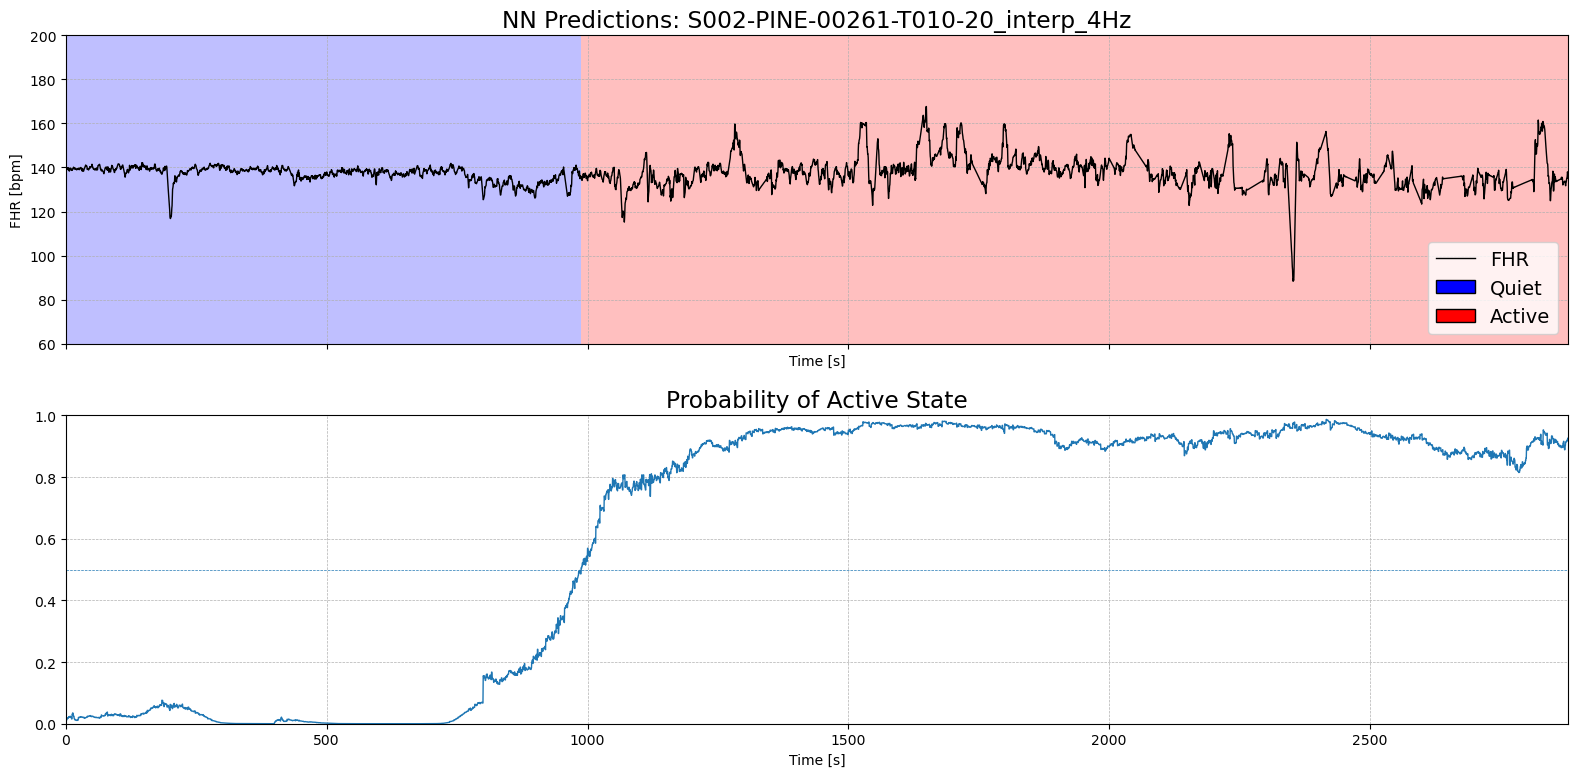

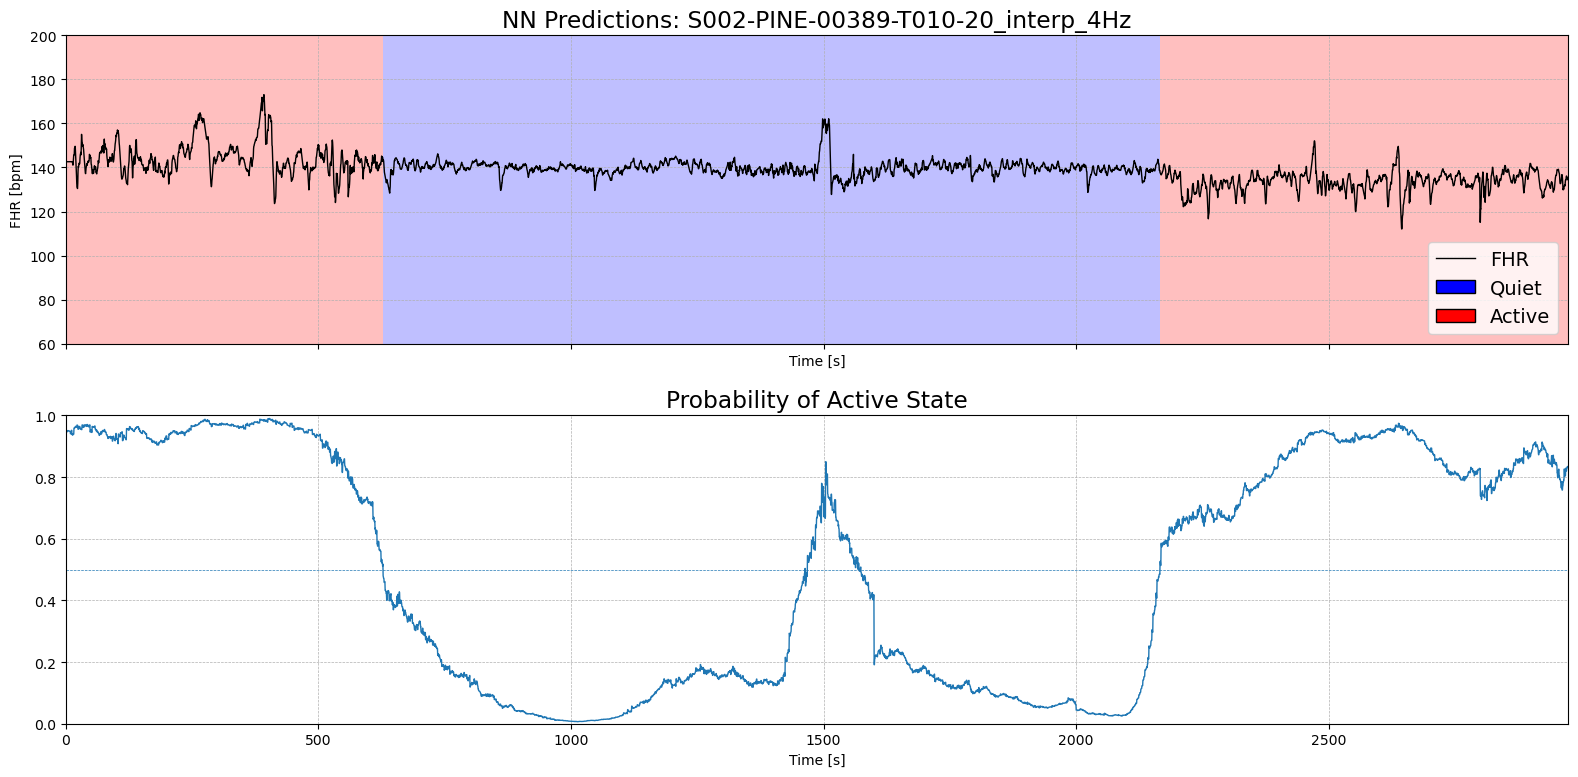

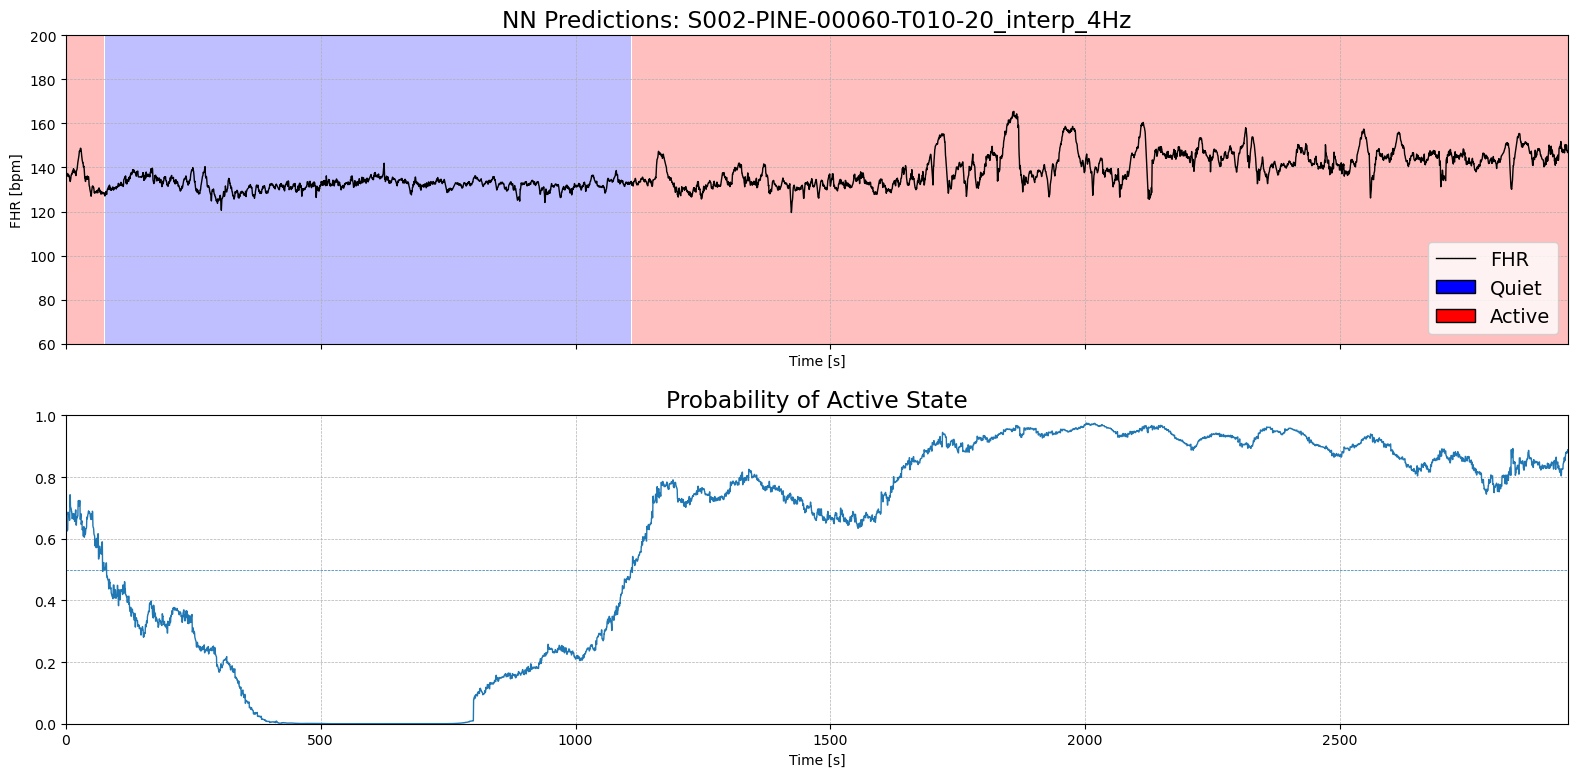

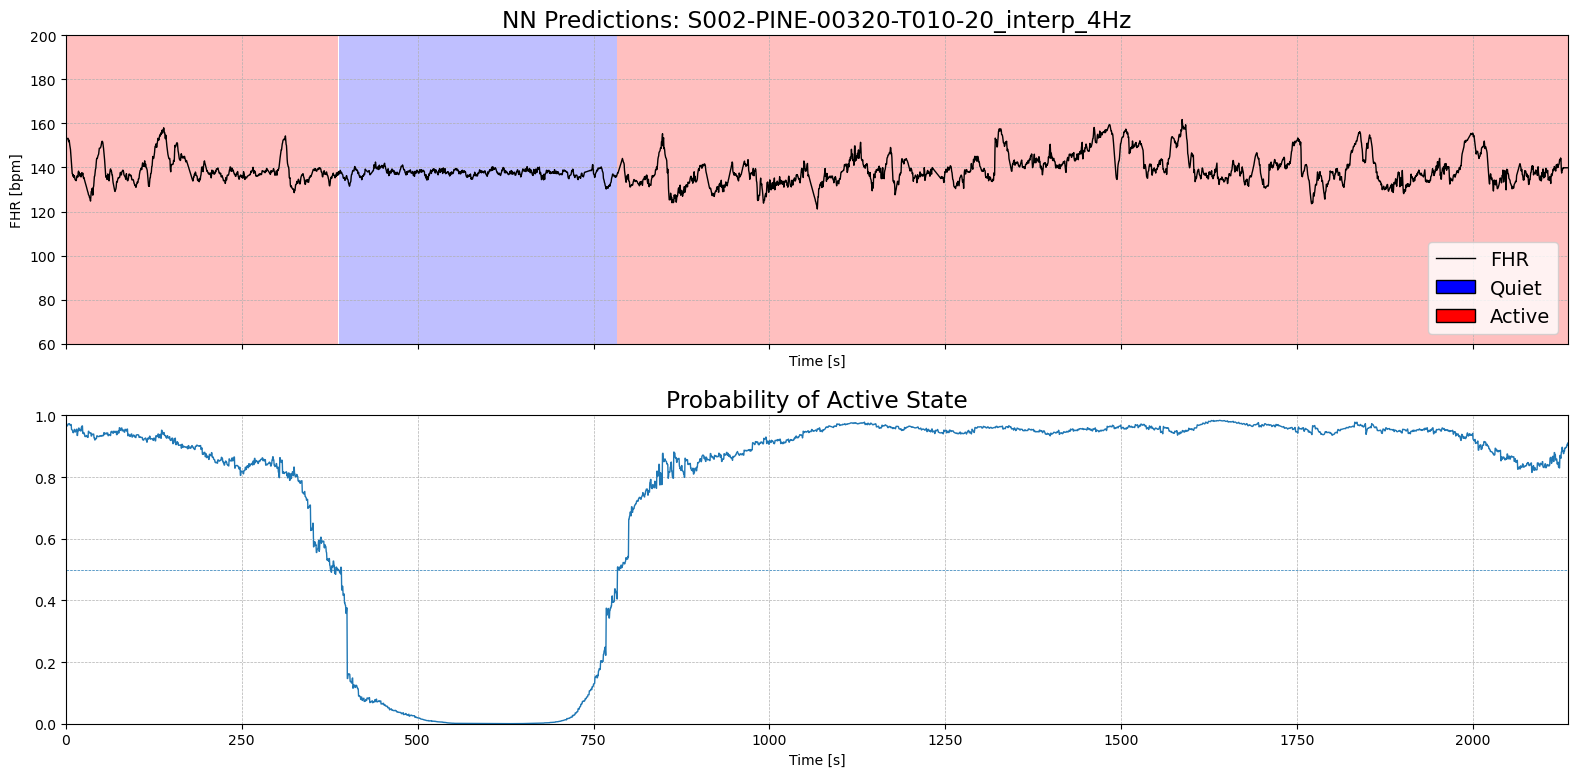

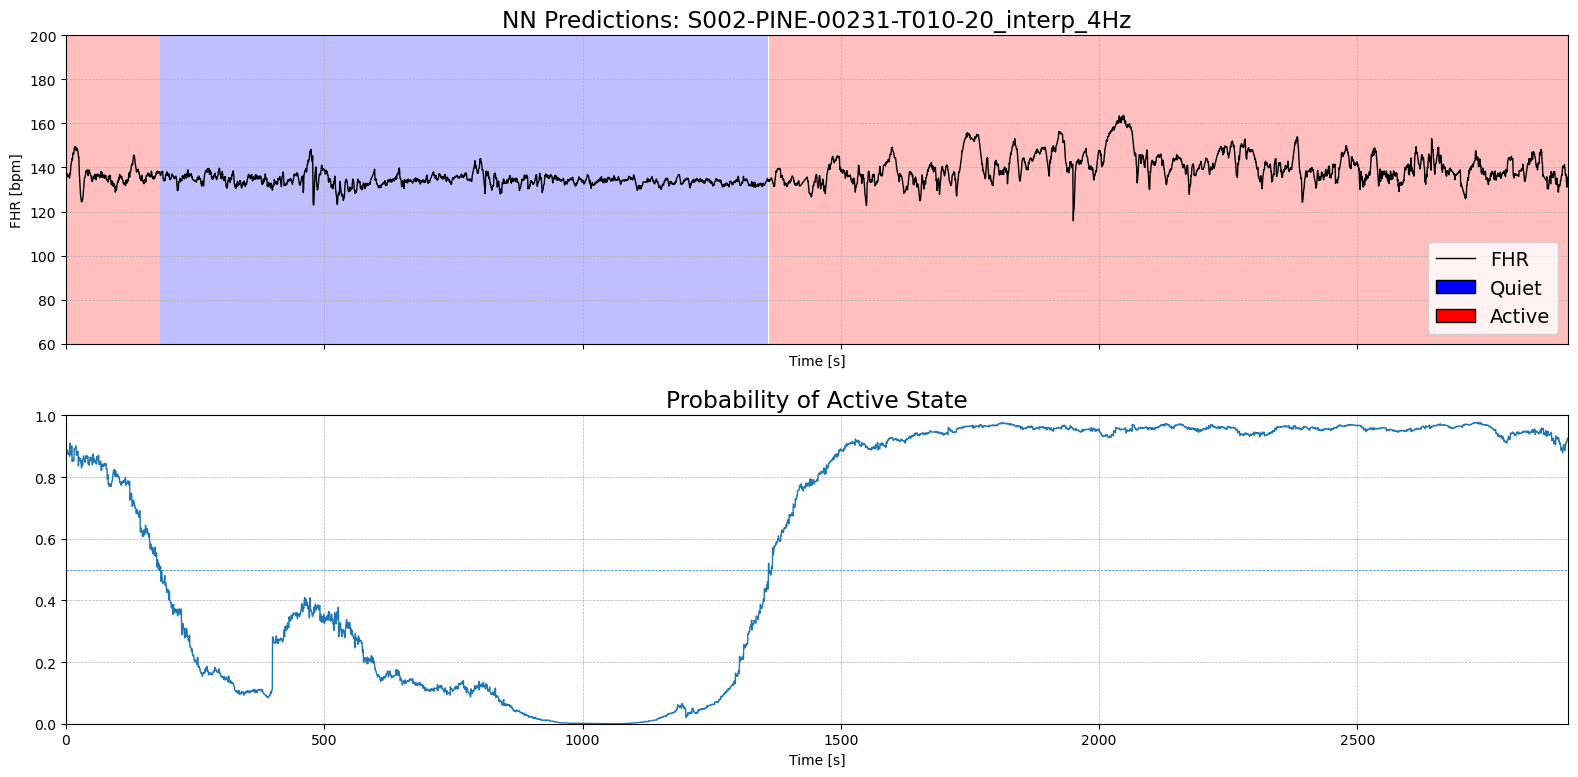

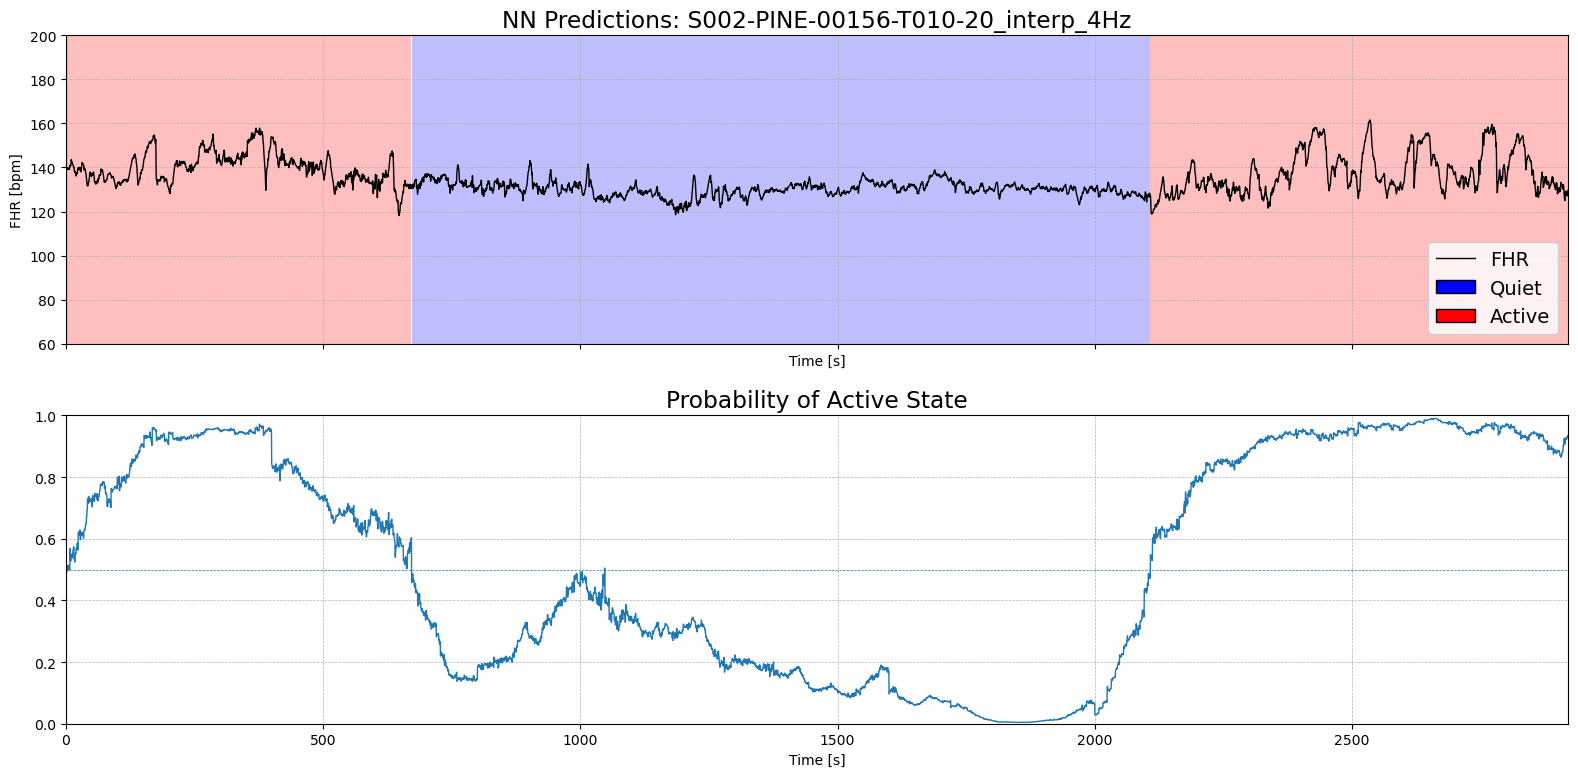

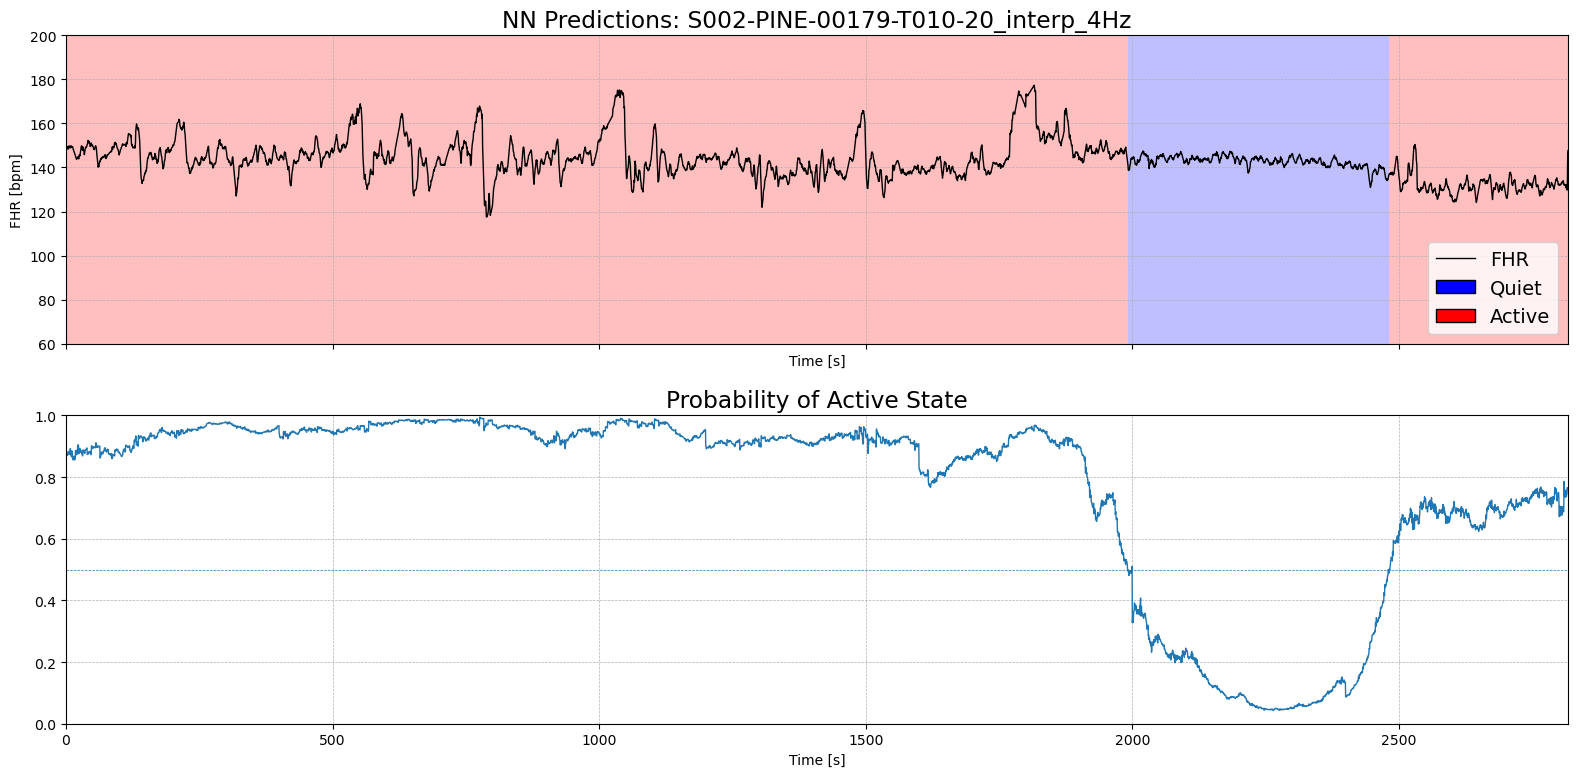

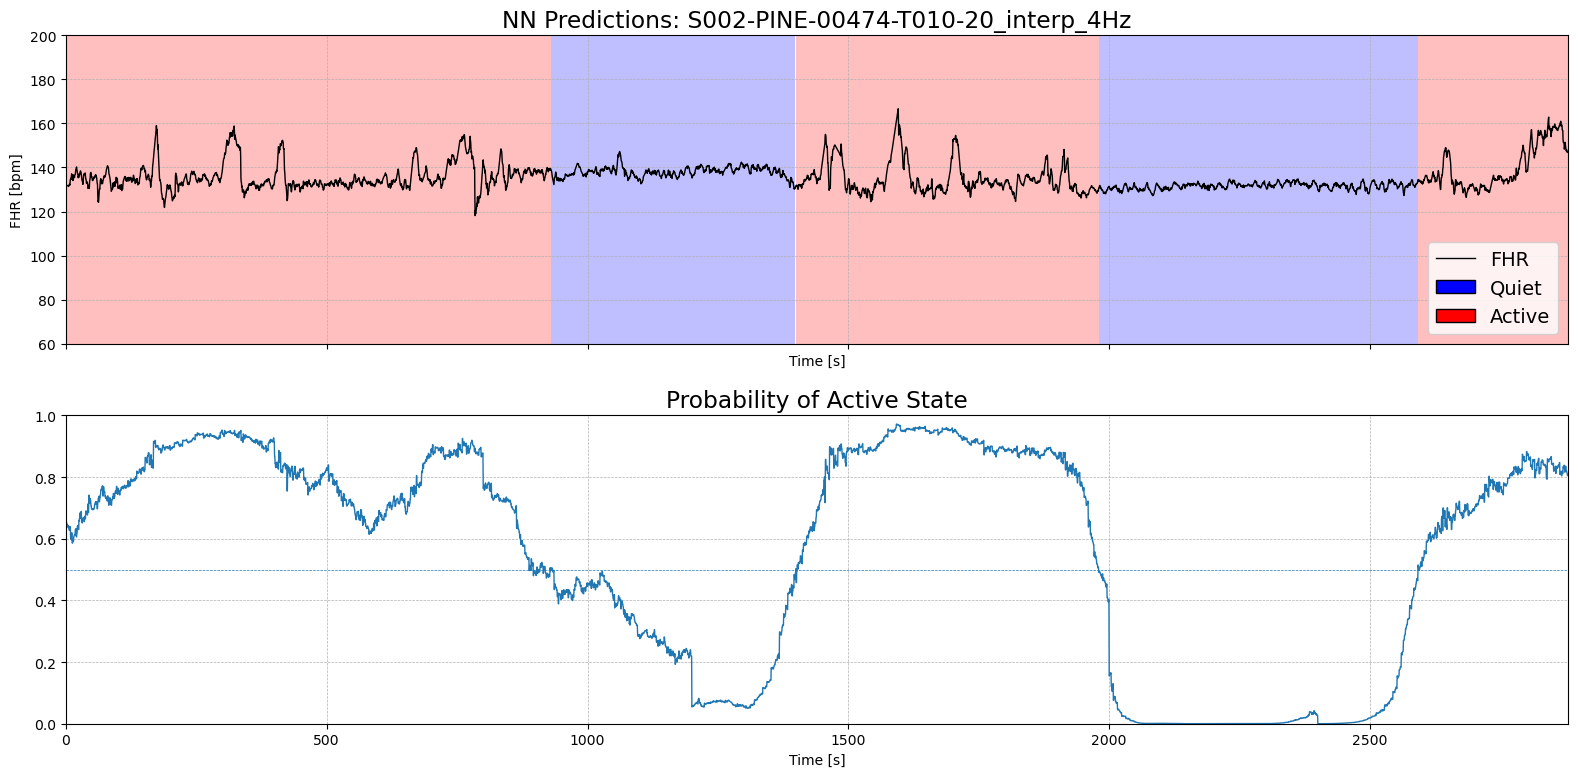

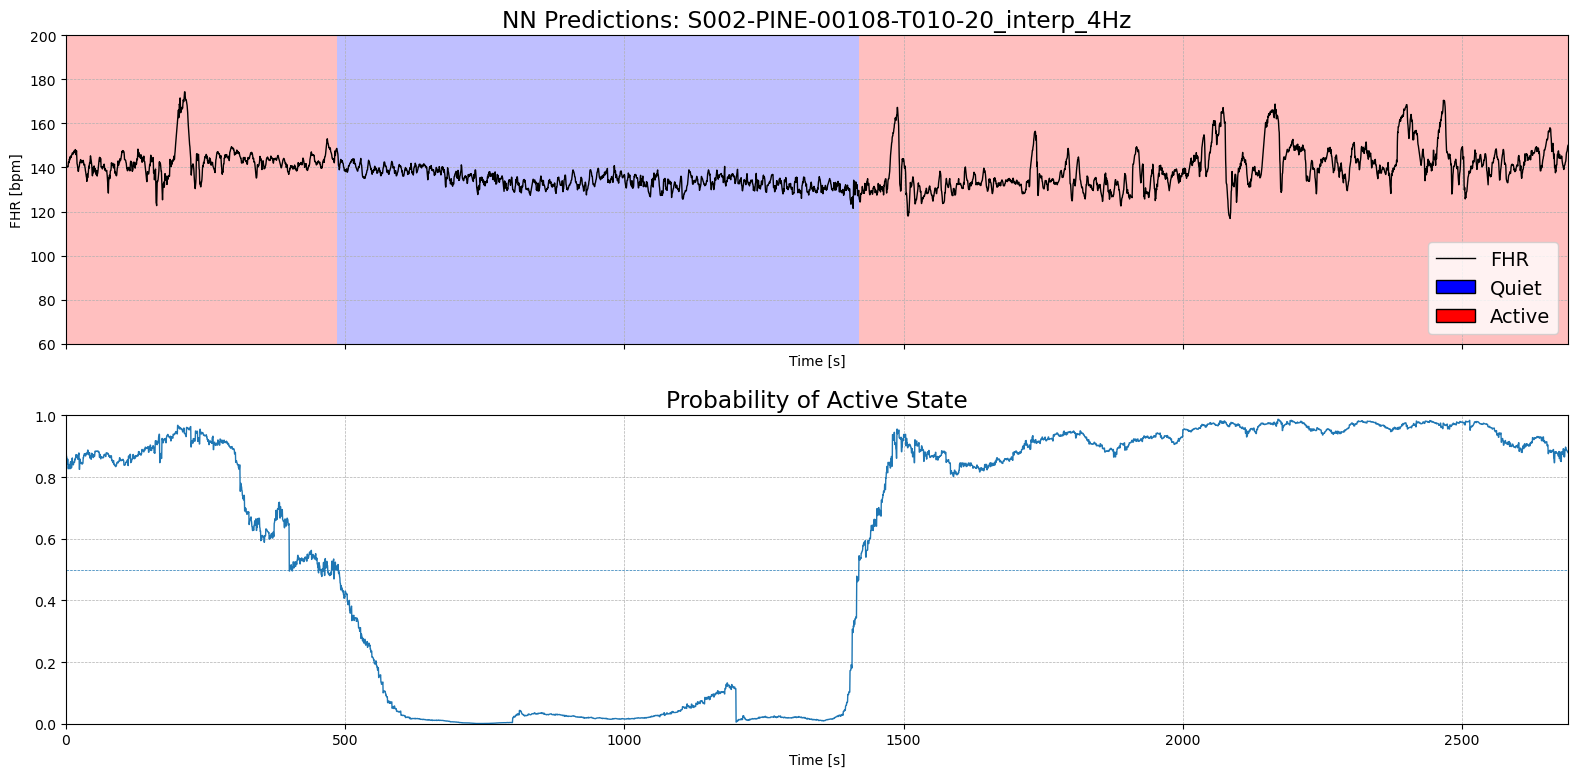

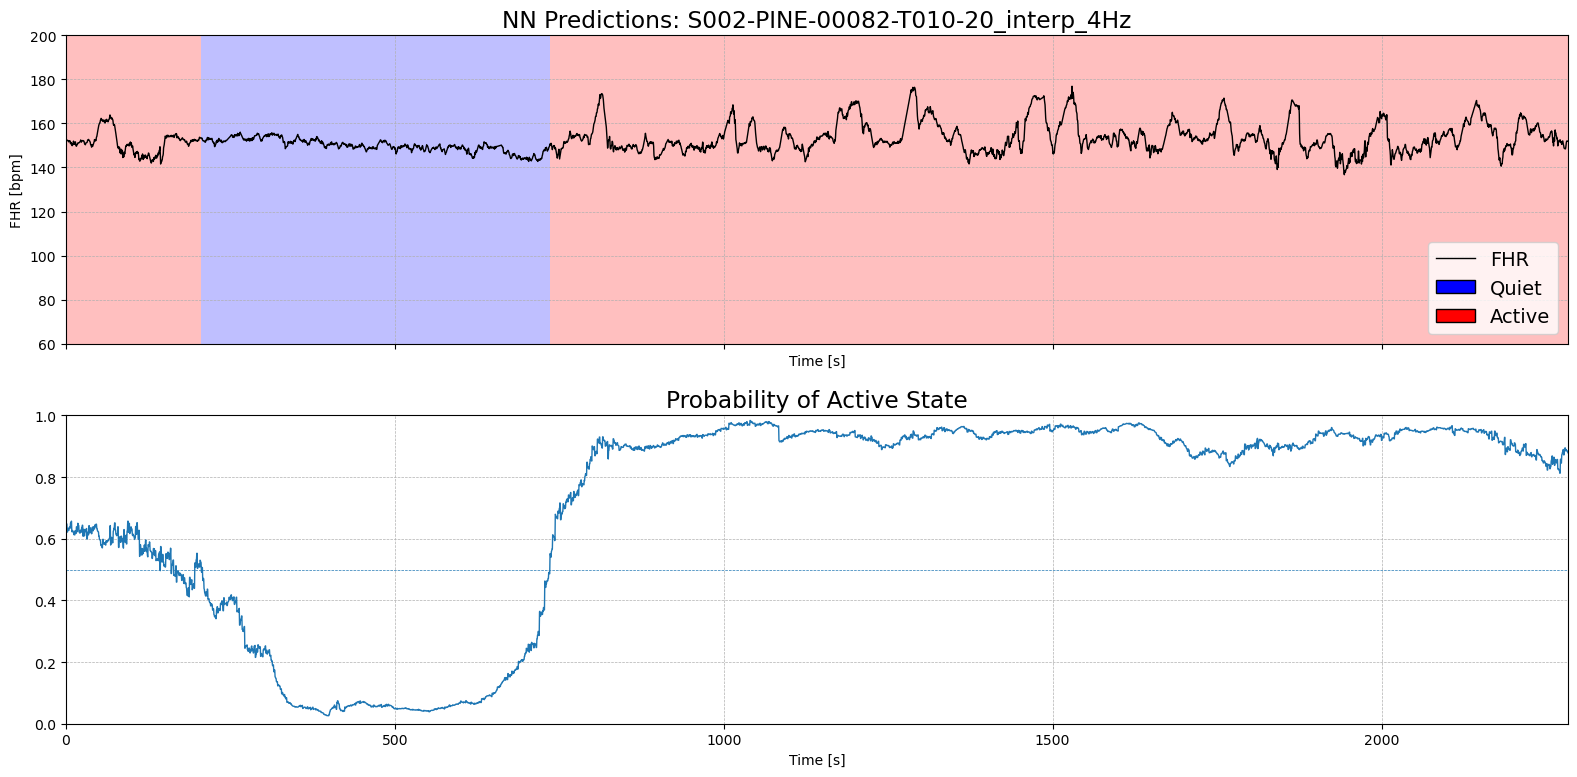

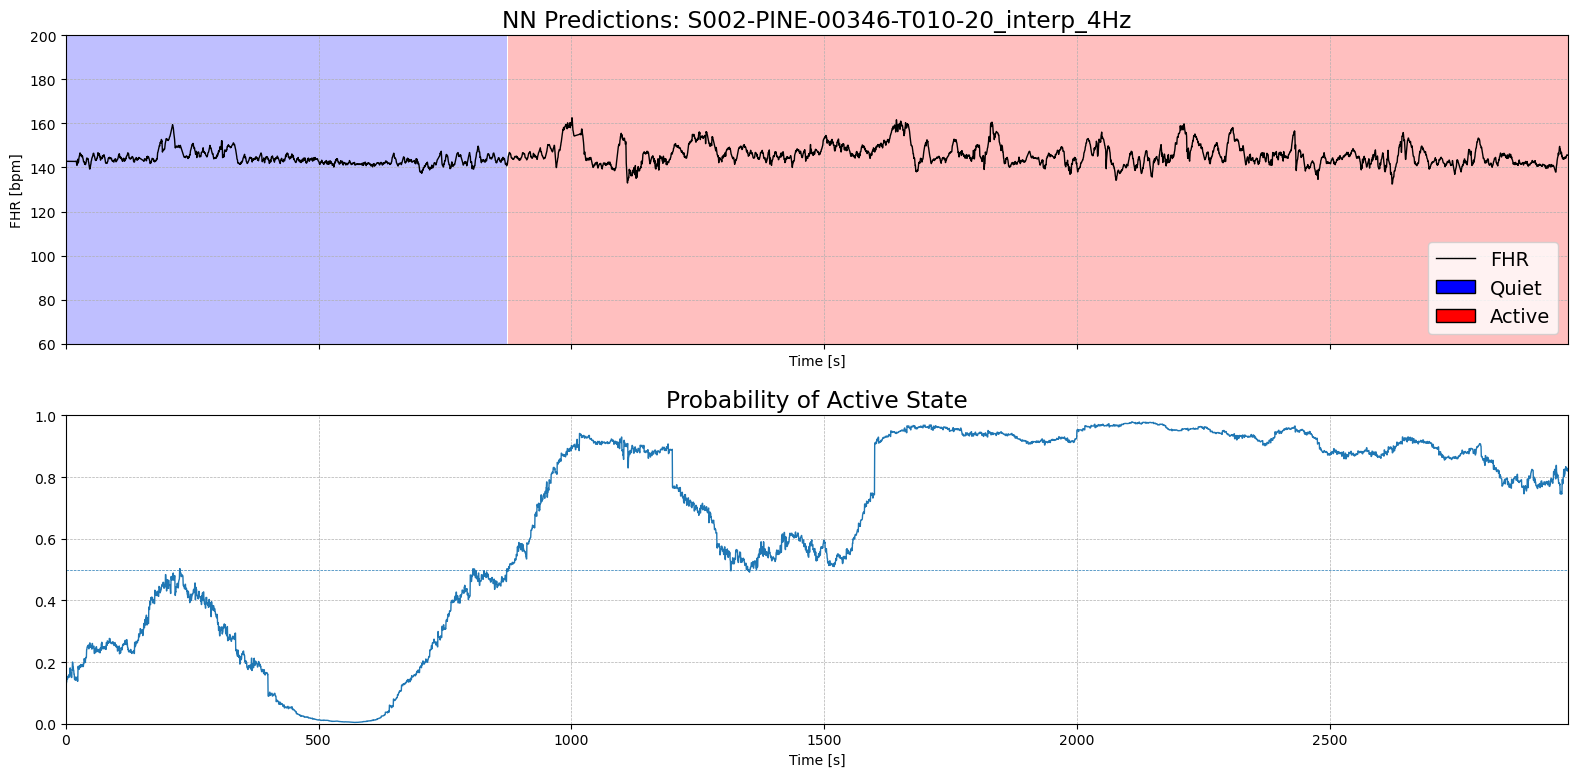

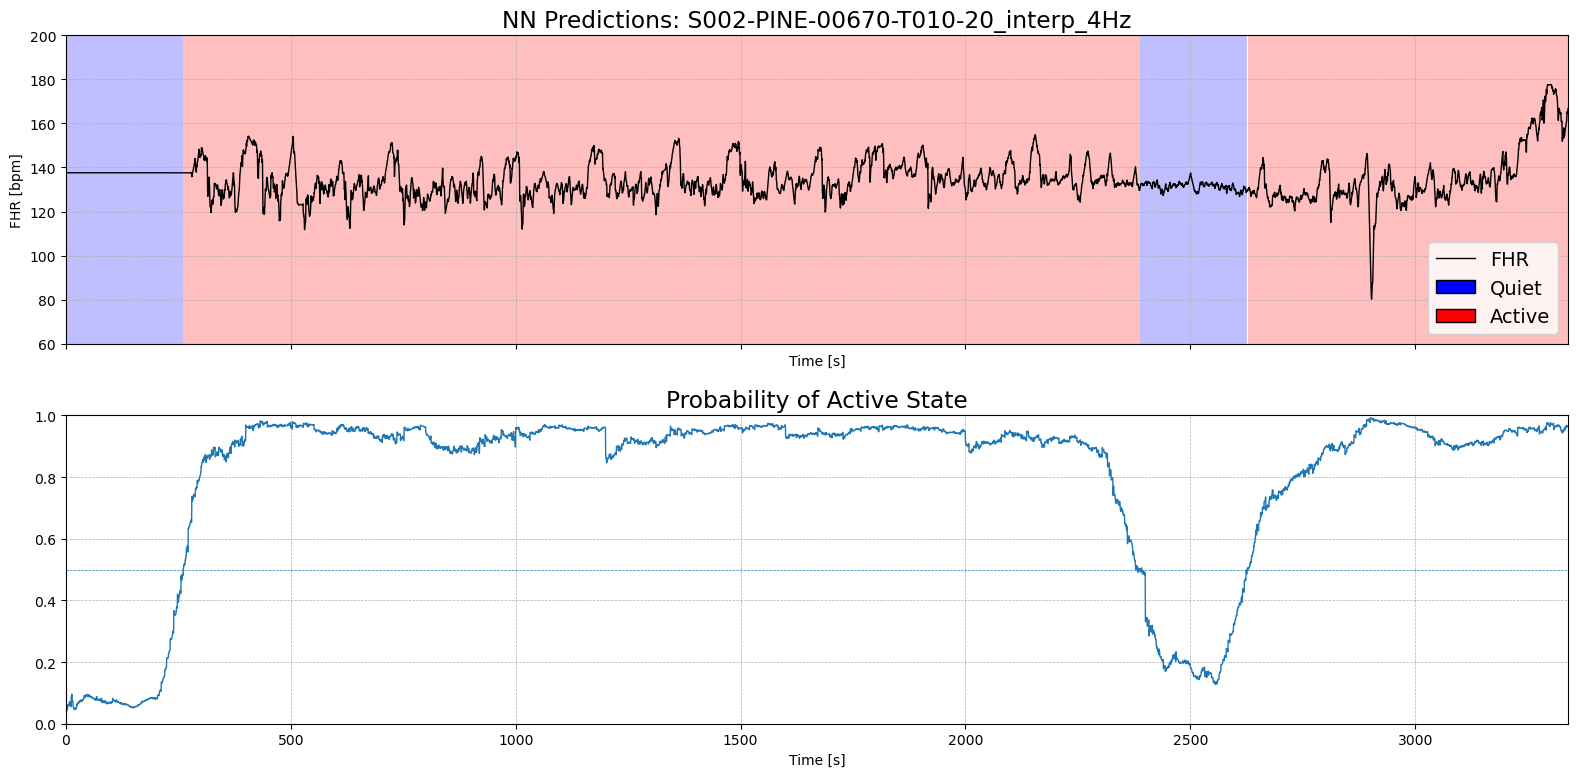

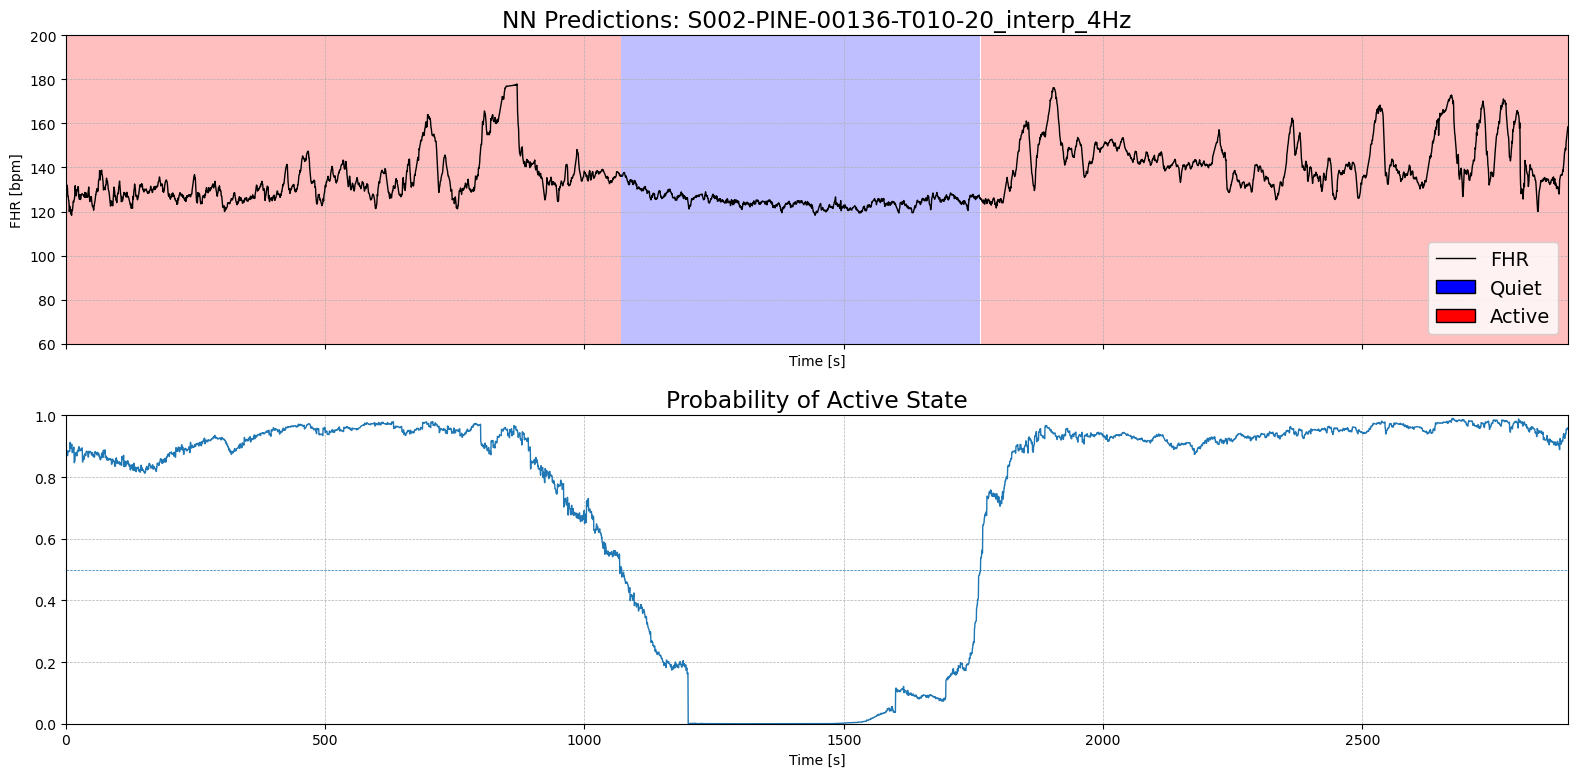

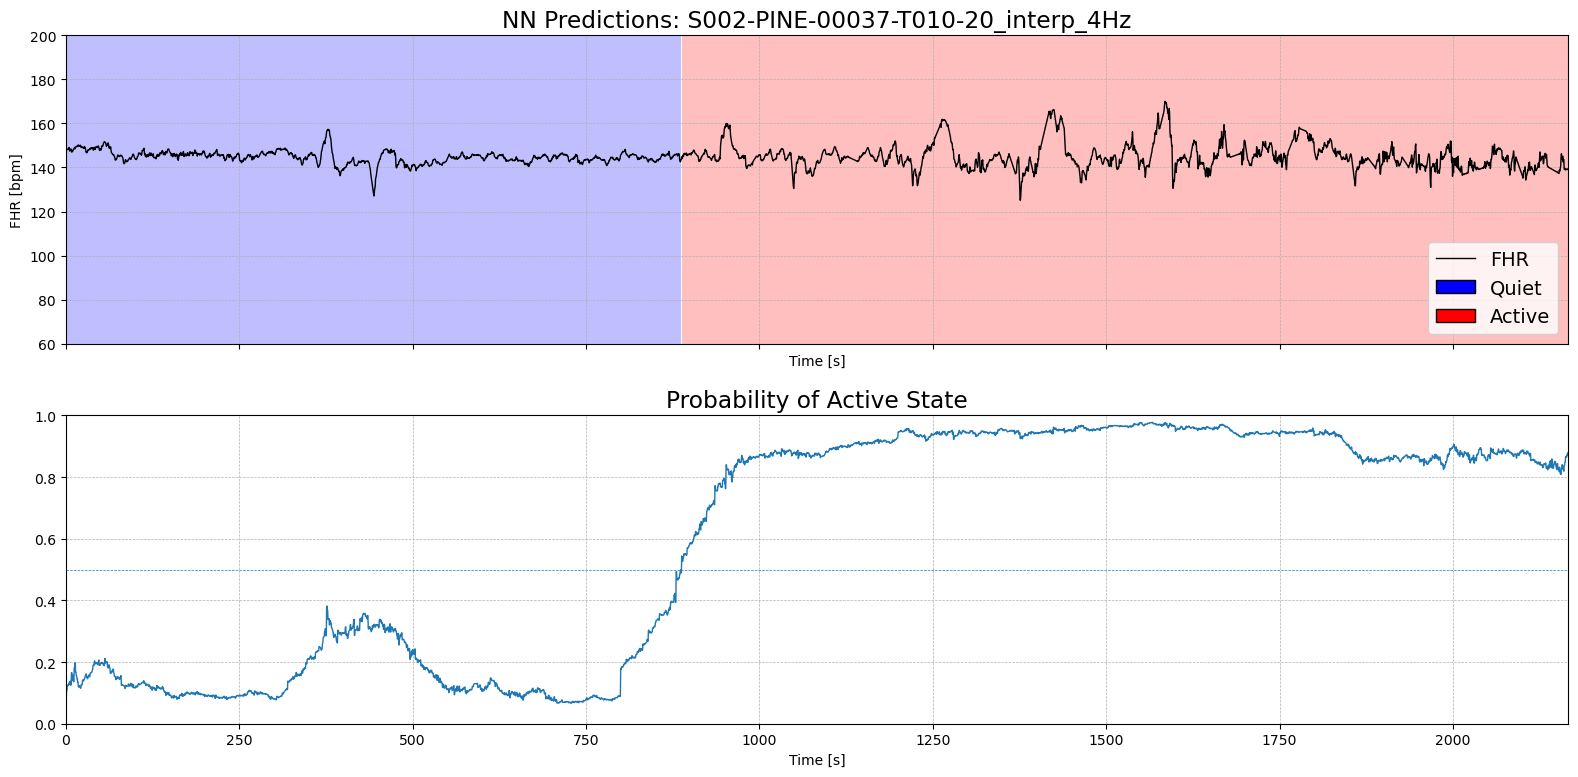

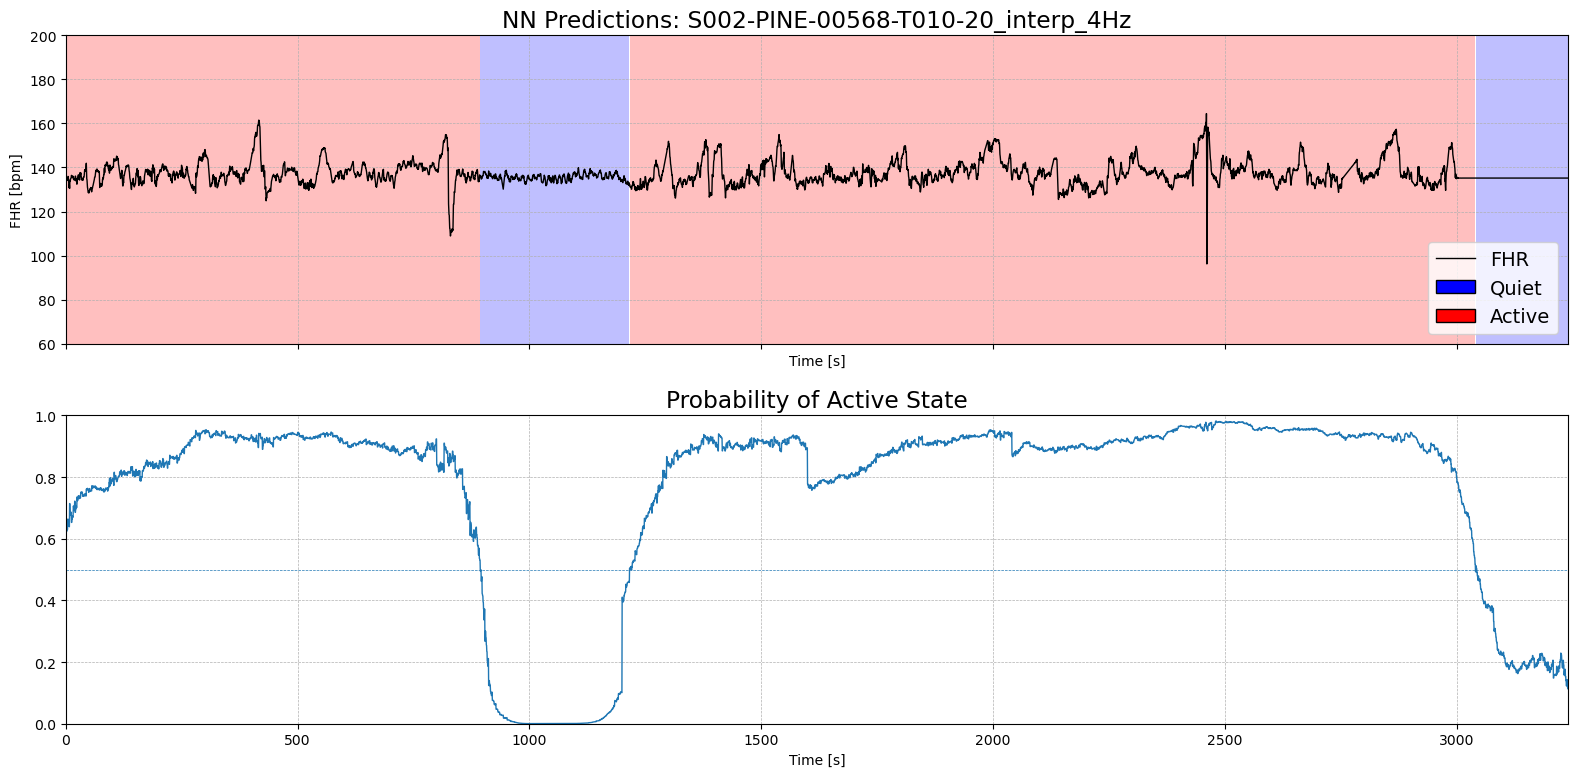

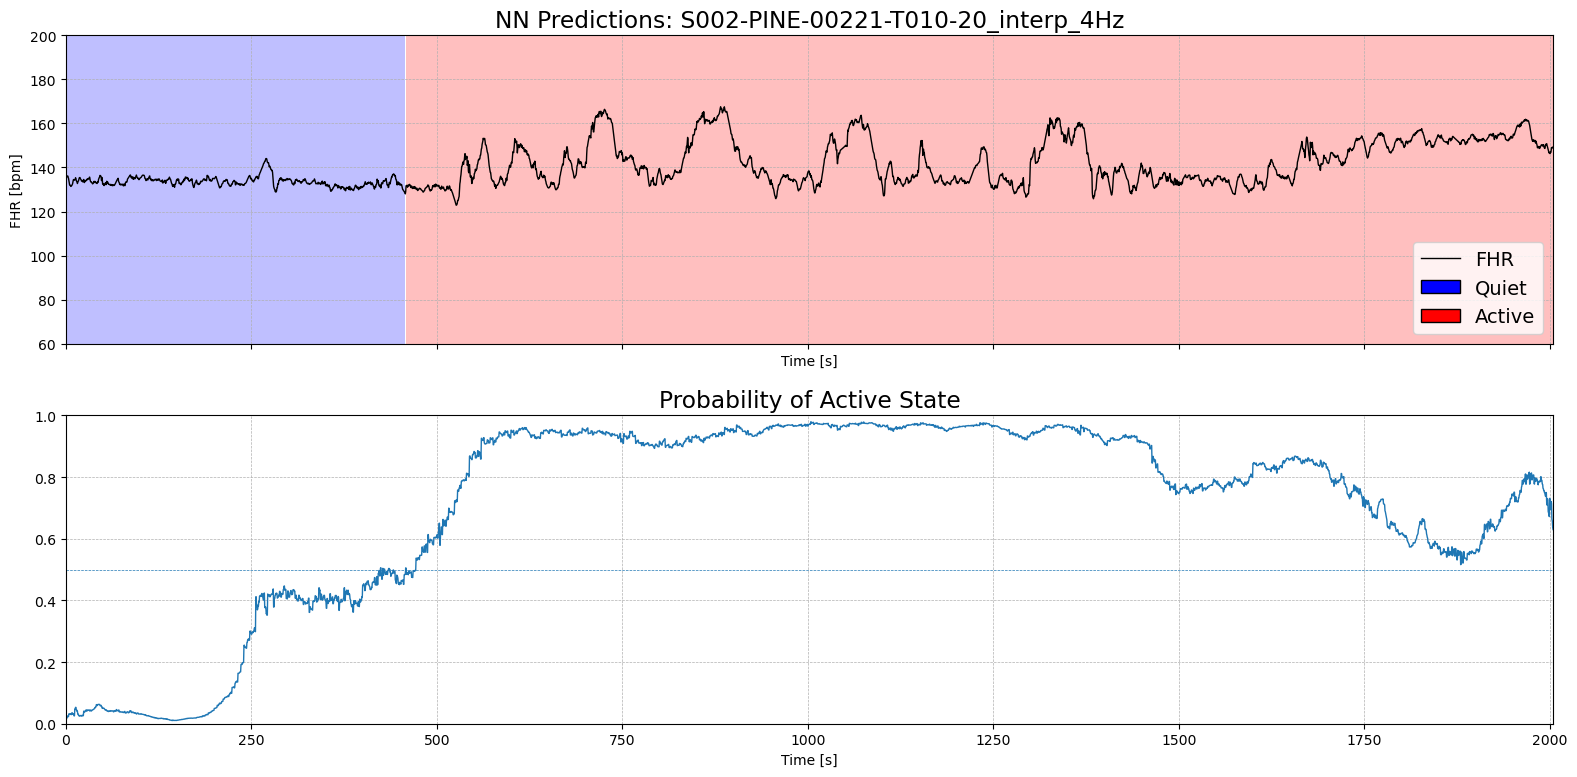

In [14]:
N_sig = len(dataset)
mapping = {'A': 1.0, 'Q': 0.0, 'T':-1}

for i in range(N_sig):

    signal = dataset[i]

    # Making the predictions
    signal, predictions, softmax_prediction_list = AQ_net_library.nn_utilities.PredictAQ(signal, model, float(fs), units, Transition = Transition, Threshold = Threshold, MinLen = MinLen, smooth=SmoothPredictions, sigma = sigma, scaling_factor = [mean, std])
    predictions = np.array([mapping[char] for char in predictions])

    titolo = "NN Predictions: " + str(dataset_names[i])
    AQ_net_library.nn_utilities.PlotResult(signal, predictions, softmax_prediction_list, 2, title = titolo)

    #saving the figure
    SavePathf = os.path.join(SavePath, dataset_names[i] + '_predictions.png')
    plt.savefig(SavePathf, bbox_inches='tight', dpi=300)
    plt.show()    

    # Saving the predictions
    np.save(os.path.join(FilePath, dataset_names[i] + '_predictions.npy'), predictions)

